In [66]:
import sys
sys.path.append('../')
import numpy as np
import matplotlib.pyplot as plt
import os
from pydicom import dcmread

from types import MappingProxyType

from DoseEngines import ModelConfig
from models.model import *
from models.layers import *
from models.data import DataGenerator
from models.utils import *
from models.kernel import *

In [67]:
if (os.path.exists('/mnt/')):
  data_path = '/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/DATASETS/ARTP/'
if (os.path.exists('/data/')):
  data_path = '/data/attila/matrad'
if (os.path.exists('/mimer/')):
  data_path = '/mimer/NOBACKUP/groups/naiss2023-6-64/matrad'

try:
  data_path = "/home/rd/Documents/github/autoplan/database/AUTORPT/"
  gen = DataGenerator(data_path, "plotting", True, 1)
except:
  data_path = "/mnt/SSD/github/autoplan/database/AUTORPT/"
  gen = DataGenerator(data_path, "plotting", True, 1)  


Number of files: 1 in plotting cohort


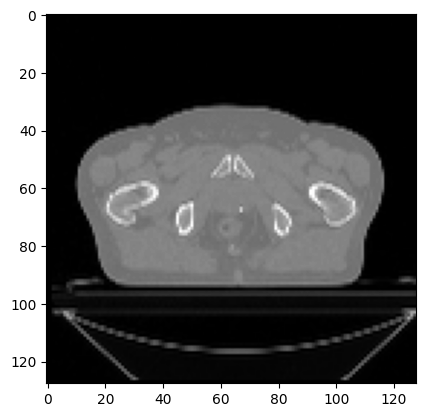

In [68]:
x, y = gen[0]
y_dose = y
x_ct = x[..., 0]
plt.imshow(x_ct[0, :, :, 160], cmap="gray")
# plt.imshow(y_dose[0, :, :, 60], cmap="jet", alpha=0.2)

In [69]:
x_ct.shape

(1, 128, 128, 320)

In [70]:
x.shape

(1, 128, 128, 320, 8)

In [71]:
for i in range(8):
    print()
    print(i)
    print(x[0,:,:,:,i].min())
    print(x[0,:,:,:,i].max())


0
-1.0
1.0

1
0.0
5.0

2
0.0
0.1

3
0.0
0.1

4
0.0
0.1

5
0.0
0.1

6
0.0
0.1

7
0.0
10.0


In [72]:
print(x_ct.max())
print(x_ct.min())

1.0
-1.0


In [73]:
def gaussian_kernel(size=7, sigma=1.5):
    """Create a normalized 2D Gaussian kernel."""
    ax = np.linspace(-(size - 1) / 2.0, (size - 1) / 2.0, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)


def gaussian_kernel_3d(size=7, sigma=1.5):
    """Create a normalized 3D Gaussian kernel."""
    ax = np.linspace(-(size - 1) / 2.0, (size - 1) / 2.0, size)
    xx, yy, zz = np.meshgrid(ax, ax, ax) # Create 3D grid
    kernel = np.exp(-(xx**2 + yy**2 + zz**2) / (2 * sigma**2)) # 3D Gaussian formula
    return kernel / np.sum(kernel) # Normalize the 3D kernel


kernel = gaussian_kernel_3d(size=7, sigma=1.5)

Text(0.5, 1.0, 'Gaussian Kernel (7x7x7)')

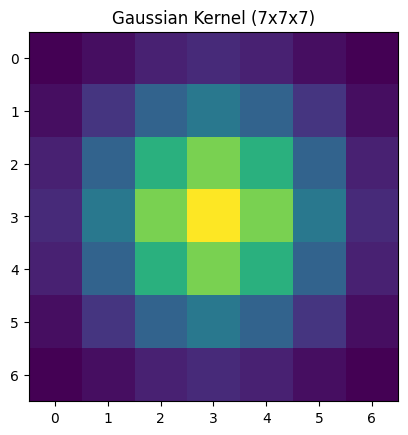

In [74]:
plt.imshow(kernel[:,:,3], cmap="viridis")
plt.title("Gaussian Kernel (7x7x7)")

In [75]:
print(kernel.min())
print(kernel.max())

4.9160009517953723e-05
0.019832563327919446


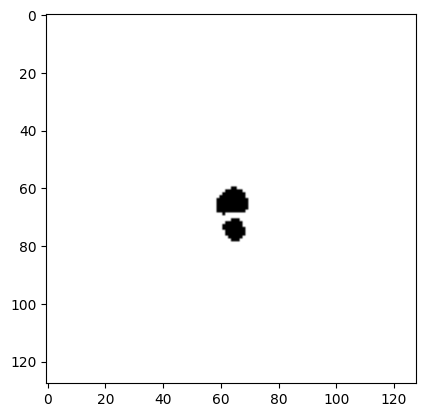

In [76]:
all_mask = x[..., -1]
plt.imshow(all_mask[0, :, :, 160], cmap="gray")

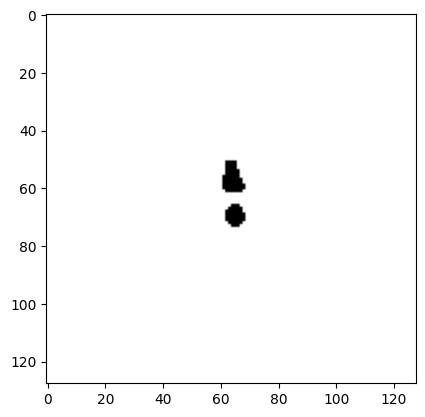

In [77]:
plt.imshow(all_mask[0, :, :, 140], cmap="gray")

In [78]:
def conv3d_numpy(input_volume, kernel):
    """
    Performs 3D convolution of a 3D input volume with a 3D kernel using NumPy.

    Args:
        input_volume (numpy.ndarray): A 3D NumPy array representing the input volume (shape: (depth, height, width)).
        kernel (numpy.ndarray): A 3D NumPy array representing the convolution kernel (shape: (kernel_depth, kernel_height, kernel_width)).

    Returns:
        numpy.ndarray: A 3D NumPy array representing the convolved output volume (shape: (output_depth, output_height, output_width)).
                       Returns None if kernel dimensions are larger than input volume dimensions in any spatial dimension.
    """

    # Get dimensions of input volume and kernel
    input_depth, input_height, input_width = input_volume.shape
    kernel_depth, kernel_height, kernel_width = kernel.shape

    # Calculate output volume dimensions (for 'valid' padding)
    output_depth = input_depth - kernel_depth + 1
    output_height = input_height - kernel_height + 1
    output_width = input_width - kernel_width + 1

    # Handle cases where kernel is larger than input in any dimension - return None or raise error
    if output_depth <= 0 or output_height <= 0 or output_width <= 0:
        print("Error: Kernel dimensions are too large for the input volume.")
        return None  # Or raise ValueError("Kernel too large for input")

    # Initialize output volume with zeros
    output_volume = np.zeros((output_depth, output_height, output_width), dtype=input_volume.dtype)

    # Perform 3D convolution using nested loops
    for d in range(output_depth):
        for h in range(output_height):
            for w in range(output_width):
                # Element-wise multiplication and summation for each kernel position
                output_volume[d, h, w] = np.sum(
                    input_volume[d:d+kernel_depth, h:h+kernel_height, w:w+kernel_width] * kernel
                )

    return output_volume

In [79]:
# Initialize an accumulator array for the sum (same shape as 3D slices)
all_mask = np.zeros(x.shape[:-1], dtype=np.float32) # Initialize with float32 for scaled values

for i in range(1, 7): # Iterate from index 1 to 6 (inclusive) along the last dimension
    slice_3d = x[..., i] # Extract 3D slice

    min_val = np.min(slice_3d)
    max_val = np.max(slice_3d)

    # Min-Max scaling to [0, 1], handle case where min == max to avoid division by zero
    if max_val > min_val:
        scaled_slice_3d = (slice_3d - min_val) / (max_val - min_val)
    else:
        scaled_slice_3d = np.zeros_like(slice_3d, dtype=np.float32) # Or np.ones_like(slice_3d) if you want to scale to [1,1] when min == max, but 0 is more typical

    all_mask += scaled_slice_3d # Add the scaled slice to the accumulator

In [80]:
all_mask.shape

(1, 128, 128, 320)

In [81]:
print(all_mask.min())
print(all_mask.max())

0.0
1.0


In [82]:
output_3d_array = conv3d_numpy(all_mask[0,:,:,:], kernel)

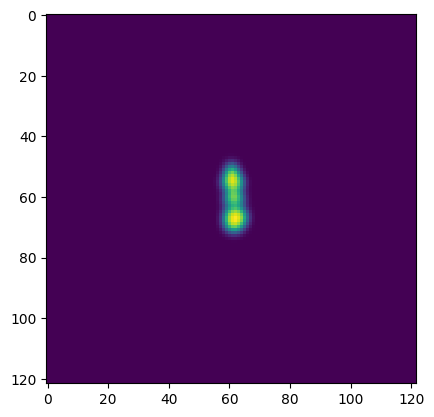

In [83]:
plt.imshow(output_3d_array[:, :, 140])

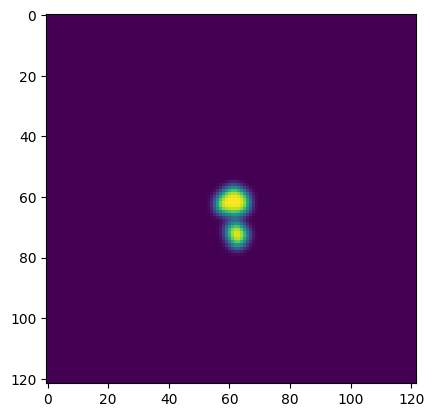

In [84]:
plt.imshow(output_3d_array[:, :, 160])

In [85]:
output_3d_array[:, :, 160]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [86]:
output_3d_array[:, :, 160].max()

1.0

In [87]:
output_3d_array[:, :, 160].min()

0.0

In [90]:
print(output_3d_array[:, :, 140].min())
print(output_3d_array[:, :, 140].max())

0.0
0.9831976


In [92]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display

def create_gif_from_3d_array(array_3d, filename="animation.gif", cmap='viridis', vmin=0, vmax=1, interpolation='nearest'):
    """
    Creates a GIF animation from a 3D NumPy array along its last dimension and displays it in a Jupyter Notebook.
    Optimized for 0-1 data display with colormap and value range control.

    Args:
        array_3d (numpy.ndarray): A 3D NumPy array (shape: (dim1, dim2, dim3)) with values typically in the range [0, 1].
                                   The animation will be created by slicing along dim3.
        filename (str, optional): The filename to save the GIF (if you want to save it). Defaults to "animation.gif".
        cmap (str or matplotlib.colors.Colormap, optional): Colormap for displaying slices. Defaults to 'viridis'.
                                                             Common options: 'viridis', 'gray', 'magma', 'inferno', 'plasma', 'cividis'.
        vmin (float, optional): Minimum value to map to the colormap. Defaults to 0.
        vmax (float, optional): Maximum value to map to the colormap. Defaults to 1.
        interpolation (str, optional): Interpolation method used when displaying slices. Defaults to 'nearest'.
                                       Options: 'nearest', 'bilinear', 'bicubic', etc. (see matplotlib imshow documentation).
    """

    if array_3d.ndim != 3:
        raise ValueError("Input array must be 3-dimensional.")

    slices = array_3d.shape[2] # Number of slices along the last dimension (dim3)

    fig = plt.figure()
    im = plt.imshow(array_3d[:, :, 0], animated=True, cmap=cmap, vmin=vmin, vmax=vmax, interpolation=interpolation) # Initialize with the first slice, use cmap for colormap

    def update_fig(i):
        im.set_array(array_3d[:, :, i])
        plt.title(f"Slice {i+1}/{slices} along Last Dimension") # Add title to each frame
        return im, # Must return a sequence

    ani = animation.FuncAnimation(fig, update_fig, frames=slices, blit=False) # blit=False is generally safer for imshow

    # Convert animation to HTML5 video (for Jupyter Notebook display)
    html_animation = ani.to_html5_video()
    plt.close(fig) # Close the figure to prevent it from displaying separately
    return html_animation


def display_gif_in_notebook(html_animation):
    """
    Displays the HTML animation in a Jupyter Notebook.

    Args:
        html_animation (str): HTML string generated by animation.to_html5_video().
    """
    display(HTML(html_animation))

In [93]:
html_gif = create_gif_from_3d_array(output_3d_array)
display_gif_in_notebook(html_gif)